
# How to use Random Forest  with Python


## import libraries 

In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import seaborn as sn


In [4]:
#step 1 read our data
df = pd.read_excel('Productivity.xlsx')
df.head()


,id,User,Time,Coffee,Age,Images_Analyzed,Productivity
0,1,1,8,0,23,20,Good
1,2,1,13,0,23,14,Bad
2,3,1,17,0,23,18,Good
3,4,1,22,0,23,15,Bad
4,5,1,8,2,23,22,Good


In [5]:
# step 2 Let's see how many values are divided into good or bad
sizes = df['Productivity'].value_counts(sort=1)
print(sizes)


Productivity
Bad     42
Good    38
Name: count, dtype: int64


### our data to be able to predict what are the independent variables into our dataset
### we drop independent variables 
### In the dataset user, Images_analyzed are independent variables so we drop it.

### drop independent variables

In [7]:
#step 3 to limit your data frame
#our data to be able to predict what are the independent variables into our dataset
#here we drop independent variables 
#In the dataset user, Images_analyzed are independent variables so we drop it.

#drop independent variables
df.drop(['Images_Analyzed'], axis=1, inplace=True)
df.drop(['User'], axis=1, inplace=True)
df.drop(['id'], axis=1, inplace=True)
df.head()

,Time,Coffee,Age,Productivity
0,8,0,23,Good
1,13,0,23,Bad
2,17,0,23,Good
3,22,0,23,Bad
4,8,2,23,Good


In [8]:
#step 4 Handle missing values
#if there is any missing value occur so it drop that overall row
df = df.dropna()  #in our dataset there is noone null value

In [9]:
# Handle non numeric data
#Convert non-numeric data into numeric data
#In our dataset good or bad let convert into 1 or 2
df.Productivity[df.Productivity == 'Good'] = 1
df.Productivity[df.Productivity == 'Bad'] = 2
print(df.head())

   Time  Coffee  Age Productivity
0     8       0   23            1
1    13       0   23            2
2    17       0   23            1
3    22       0   23            2
4     8       2   23            1


/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_13788/2178167910.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.Productivity[df.Productivity == 'Good'] = 1
/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_13788/2

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Time          80 non-null     int64 
 1   Coffee        80 non-null     int64 
 2   Age           80 non-null     int64 
 3   Productivity  80 non-null     object
dtypes: int64(3), object(1)
memory usage: 2.6+ KB


In [12]:
#Define dependent variable 
Y = df['Productivity'].values
#Convert Y object into integer 
Y=Y.astype('int')
df.head(2)

,Time,Coffee,Age,Productivity
0,8,0,23,1
1,13,0,23,2


In [13]:
#Define independent variables
X = df.drop(labels=['Productivity'], axis=1)
X

,Time,Coffee,Age
0,8,0,23
1,13,0,23
2,17,0,23
3,22,0,23
4,8,2,23
...,...,...,...
75,23,4,52
76,9,6,52
77,14,6,52
78,17,6,52


In [14]:
Y

array([1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1,
       1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2])

In [15]:
#step 6 Split our data into Training and Testing dataset
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state =0)

In [16]:
#step 7
#Apply random forest
#we use RandomForestClassifier because in our dataset Productivity it's classify the value into  good or bad
from sklearn.ensemble import RandomForestClassifier 
model = RandomForestClassifier(n_estimators=10, random_state=30)



In [17]:
#fit data
model.fit(X_train, Y_train)

#Predict our dataset
prediction_test = model.predict(X_test)
print(prediction_test)
len(prediction_test)



[1 2 2 2 2 2 1 1 1 2 1 2 2 1 1 1]


16

In [18]:
#find our prediction accuracy
from sklearn import metrics
print("Accuracy = ", metrics.accuracy_score(Y_test, prediction_test))

#find what parameters or features occurs in our model
features_list = list(X.columns)
feature_imp = pd.Series(model.feature_importances_, index=features_list).sort_values(ascending=False) 
print(feature_imp)



Accuracy =  0.9375
Time      0.671062
Coffee    0.214131
Age       0.114806
dtype: float64


<Axes: xlabel='Predicted', ylabel='Actual'>

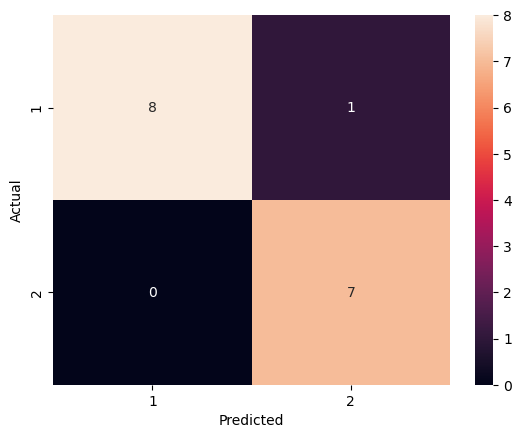

In [19]:
Y_pred = prediction_test
import seaborn as sn
confusion_matrix = pd.crosstab(Y_test, Y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(confusion_matrix, annot=True)
#confusion_matrix

